# The Silicon Canary — a quantitative teardown \U0001F52C
### Rolling-beta residuals · two-directional lead-lag · horizon-lag HAC · peer and tech controls

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Three controls
carry the study: the **reverse direction** (does the market lead the semis just as much?), a
**second semiconductor fund** (is this about chips or about an index?), and **XLK** (is this
about chips or about technology?).

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date
> in [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from semi_lead import data, strategy as st

px = data.load_prices()
rets = st.to_returns(px)
common = rets[list(data.TICKERS)].dropna()
print(f"as-of {data.AS_OF} | common window {common.index[0].date()} -> "
      f"{common.index[-1].date()} ({len(common):,} sessions)")
print(f"raw correlation {data.CANARY} vs {data.MARKET}: "
      f"{common[data.CANARY].corr(common[data.MARKET]):.3f}")
resid = st.residual_series(common, data.CANARY, data.MARKET).dropna()
print(f"after removing a rolling beta: "
      f"{resid.corr(common[data.MARKET].reindex(resid.index)):+.3f}")

as-of 2026-06-30 | common window 2007-05-31 -> 2026-06-30 (4,801 sessions)
raw correlation SMH vs SPY: 0.791
after removing a rolling beta: +0.003


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Weak | Once the market factor is regressed out, the canary is much quieter than the folklore. At lag 1 the semiconductor residual leads the market with correlation **+0.044** while the market leads it by -0.088 — a difference of **+0.132**. The headline predictive regression (trailing 21-day residual → next 21-day market return) gives a slope of +2.35 with HAC *t* = **+1.59** and an R² of 1.044%; **0 of 2** semiconductor funds clear |*t*| = 2, and **7** of the 12 lookback × horizon cells do, against 0.6 expected by luck. The non-semiconductor control (XLK) scores +1.60 — if the effect were about chips rather than about tech, that number should be small. |
| **Tradability** | Fragile | The rule — own the market while the canary's trailing relative strength is positive, hold bills otherwise — was invested 55% of the time, switched 25.2 times a year, and returned **+10.19%/yr** against **+10.70%/yr** for simply owning the market (-0.51%/yr, Sharpe +0.74 vs +0.61, HAC *t* on the daily difference -0.47). Its drawdown was -31.4% against -55.2% — the risk reduction is real; the return is not. |

> \U0001F4A1 **In plain words.** There is a small genuine lead. It is not large enough, not
> specific enough to semiconductors, and not stable enough across eras to trade.

## 1 · The claim, made testable

- **H₁.** corr(semi residual at *t*, market at *t+1*) > corr(market at *t*, semi residual at
  *t+1*). Leading, not co-moving.
- **H₂.** The trailing semi residual predicts the market's next-month return with a positive
  slope and |*t*| ≥ 2 under horizon-lag HAC errors.
- **H₃.** The effect appears in **both** semiconductor funds and is *weaker* in the broad tech
  fund. If it is equally strong in XLK, the hypothesis under test is a different one.
- **H₄.** The implied timing rule beats buy-and-hold after costs.

## 2 · Removing the market, two ways

raw                   0.7938
minus market          0.2442
minus beta x market   0.0031


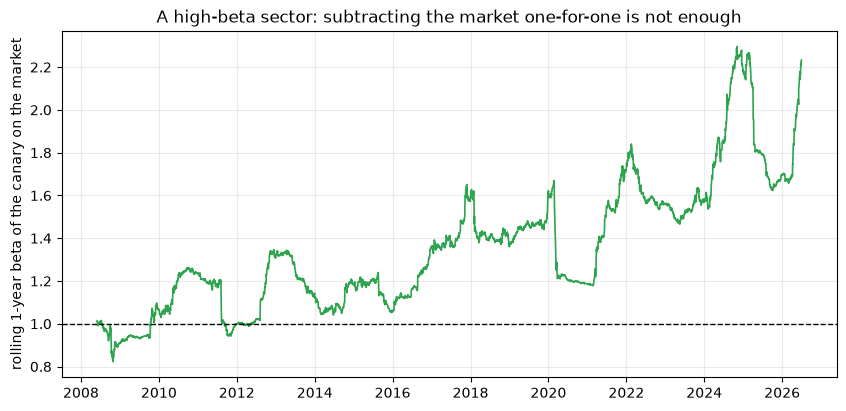

In [3]:
rs = st.relative_strength(common, data.CANARY, data.MARKET)
res = st.residual_series(common, data.CANARY, data.MARKET)
d = pd.DataFrame({"raw": common[data.CANARY], "minus market": rs,
                  "minus beta x market": res}).dropna()
print(d.corrwith(common[data.MARKET].reindex(d.index)).round(4).to_string())
fig, ax = plt.subplots(figsize=(10, 4.5))
beta = (common[data.CANARY].rolling(252).cov(common[data.MARKET])
        / common[data.MARKET].rolling(252).var())
ax.plot(beta.index, beta, lw=1.2, color="#2ea44f")
ax.axhline(1.0, color="k", lw=1, ls="--")
ax.set_ylabel("rolling 1-year beta of the canary on the market")
ax.set_title("A high-beta sector: subtracting the market one-for-one is not enough")
plt.show()

## 3 · The teardown

### 3.1 Lead-lag with its mirror, both signal definitions

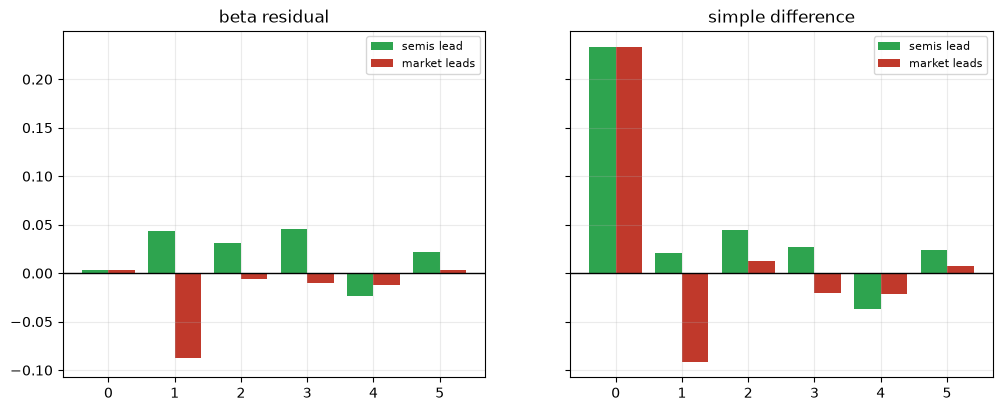

     sector_leads  market_leads  difference
lag                                        
0          0.0031        0.0031      0.0000
1          0.0440       -0.0878      0.1318
2          0.0310       -0.0059      0.0369
3          0.0452       -0.0102      0.0554
4         -0.0237       -0.0123     -0.0114
5          0.0217        0.0032      0.0185


In [4]:
a = st.lead_lag_table(common, data.CANARY, data.MARKET, max_lag=5, use_residual=True)
b = st.lead_lag_table(common, data.CANARY, data.MARKET, max_lag=5, use_residual=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, t, name in ((axes[0], a, "beta residual"), (axes[1], b, "simple difference")):
    x = np.arange(len(t))
    ax.bar(x - 0.2, t["sector_leads"], width=0.4, color="#2ea44f", label="semis lead")
    ax.bar(x + 0.2, t["market_leads"], width=0.4, color="#c0392b", label="market leads")
    ax.set_xticks(x); ax.set_xticklabels(t.index); ax.axhline(0, color="k", lw=1)
    ax.set_title(name); ax.legend(fontsize=8)
plt.show()
print(a.round(4).to_string())

### 3.2 The regression grid, and its multiplicity

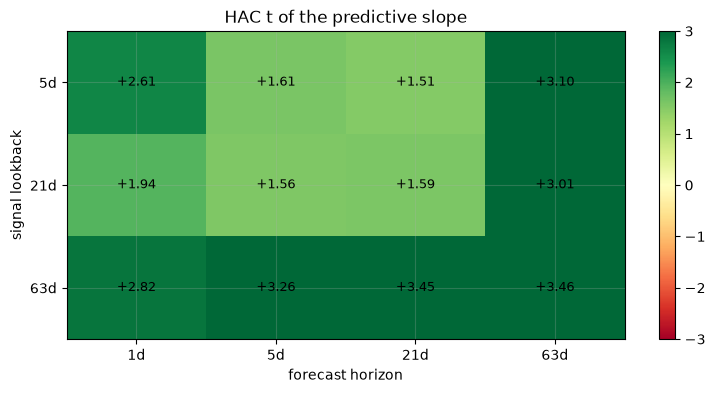

7 of 12 cells clear |t| = 2; luck alone gives 0.60
 lookback  horizon    beta      t     r2    n
        5        1  0.1539 2.6072 0.0033 4544
        5        5  0.2448 1.6096 0.0021 4540
        5       21  0.5514 1.5147 0.0028 4524
        5       63  1.8965 3.0951 0.0124 4482
       21        1  0.2223 1.9361 0.0014 4528
       21        5  0.6129 1.5554 0.0027 4524
       21       21  2.3490 1.5885 0.0104 4508
       21       63  7.9800 3.0061 0.0441 4466
       63        1  0.6188 2.8191 0.0030 4486
       63        5  2.5427 3.2632 0.0126 4482
       63       21  9.5783 3.4546 0.0467 4466
       63       63 21.3660 3.4621 0.0959 4424


In [5]:
grid = st.horizon_grid(common, data.CANARY, data.MARKET)
piv = grid.pivot(index="lookback", columns="horizon", values="t")
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(piv.values, cmap="RdYlGn", vmin=-3, vmax=3, aspect="auto")
ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels([f"{c}d" for c in piv.columns])
ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels([f"{i}d" for i in piv.index])
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        ax.text(j, i, f"{piv.values[i, j]:+.2f}", ha="center", va="center", fontsize=9)
ax.set_xlabel("forecast horizon"); ax.set_ylabel("signal lookback")
ax.set_title("HAC t of the predictive slope")
fig.colorbar(im, ax=ax)
plt.show()
n = int((grid["t"].abs() >= 2).sum())
print(f"{n} of {len(grid)} cells clear |t| = 2; luck alone gives "
      f"{st.expected_false_positives(len(grid)):.2f}")
print(grid.round(4).to_string(index=False))

> \U0001F4A1 **In plain words.** Twelve cells is twelve chances. Reporting the best one without
> the other eleven is the oldest trick in the literature.

### 3.3 The two controls

          beta       t     r2  cagr_gap  sharpe_gap   t_gap  time_invested
canary                                                                    
SMH     2.3490  1.5885 0.0104   -0.0051      0.1298 -0.4713         0.5457
SOXX    2.3022  1.6082 0.0112   -0.0004      0.1658 -0.3116         0.5309
XLK     5.2007  1.5959 0.0139   -0.0017      0.1388 -0.3577         0.5330
QQQ     4.8807  1.2316 0.0105   -0.0235      0.0133 -1.0845         0.5309
IWM    -0.5830 -0.2984 0.0003   -0.0345      0.0216 -1.3393         0.4474


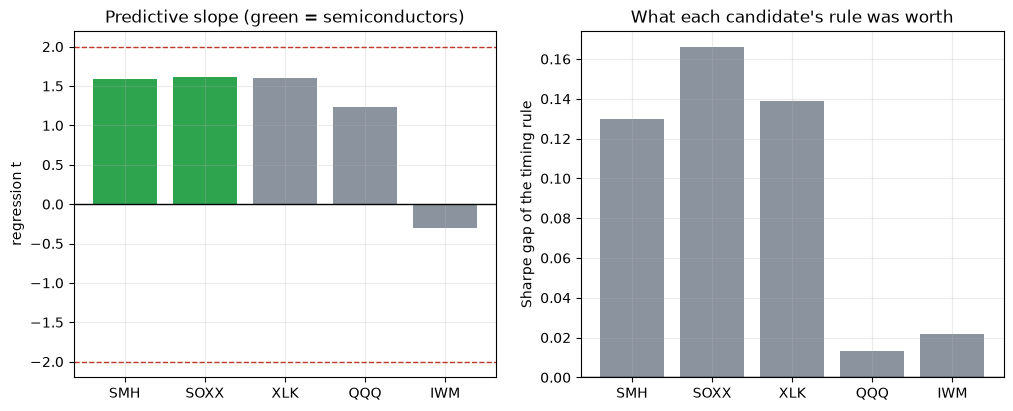

In [6]:
peers = st.peer_agreement(common, data.MARKET, data.CASH,
                          [data.CANARY] + list(data.PEERS) + [c for c in data.OTHERS],
                          lookback=21, horizon=21)
print(peers.round(4).to_string())
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(peers.index, peers["t"], color=["#2ea44f" if c in ("SMH", "SOXX") else "#8b949e"
                                            for c in peers.index])
axes[0].axhline(2, ls="--", color="#c0392b", lw=1); axes[0].axhline(-2, ls="--", color="#c0392b", lw=1)
axes[0].axhline(0, color="k", lw=1); axes[0].set_ylabel("regression t")
axes[0].set_title("Predictive slope (green = semiconductors)")
axes[1].bar(peers.index, peers["sharpe_gap"], color="#8b949e")
axes[1].axhline(0, color="k", lw=1); axes[1].set_ylabel("Sharpe gap of the timing rule")
axes[1].set_title("What each candidate's rule was worth")
plt.show()

### 3.4 The rule, swept

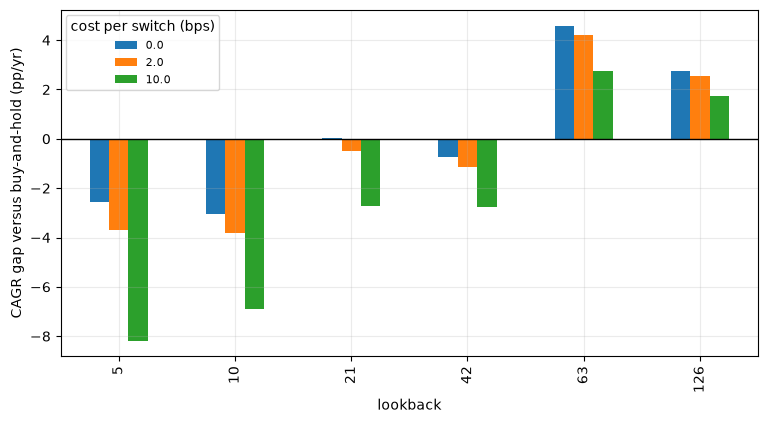

' lookback  cost_bps  cagr_gap  sharpe_gap  switches\n        5    0.0000   -0.0256     -0.0061   53.3289\n        5    2.0000   -0.0371     -0.0790   53.3289\n        5   10.0000   -0.0818     -0.3703   53.3289\n       10    0.0000   -0.0305     -0.0330   36.2699\n       10    2.0000   -0.0383     -0.0830   36.2699\n       10   10.0000   -0.0688     -0.2830   36.2699\n       21    0.0000    0.0005      0.1647   25.2472\n       21    2.0000   -0.0051      0.1298   25.2472\n       21   10.0000   -0.0271     -0.0100   25.2472\n       42    0.0000   -0.0072      0.1307   18.6336\n       42    2.0000   -0.0113      0.1042   18.6336\n       42   10.0000   -0.0276     -0.0017   18.6336\n       63    0.0000    0.0459      0.4846   16.1141\n       63    2.0000    0.0422      0.4614   16.1141\n       63   10.0000    0.0275      0.3682   16.1141\n      126    0.0000    0.0274      0.3839    8.7657\n      126    2.0000    0.0254      0.3709    8.7657\n      126   10.0000    0.0175      0.3189    

In [7]:
rows = []
for lb in (5, 10, 21, 42, 63, 126):
    for cost in (0.0, 2.0, 10.0):
        r = st.timing_rule(common, data.CANARY, data.MARKET, data.CASH,
                           lookback=lb, cost_bps=cost)
        rows.append({"lookback": lb, "cost_bps": cost, "cagr_gap": r["cagr_gap"],
                     "sharpe_gap": r["sharpe_gap"], "switches": r["switches_per_year"]})
d = pd.DataFrame(rows)
piv = d.pivot(index="lookback", columns="cost_bps", values="cagr_gap")
fig, ax = plt.subplots(figsize=(9, 4.5))
(piv * 100).plot.bar(ax=ax)
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("CAGR gap versus buy-and-hold (pp/yr)")
ax.legend(title="cost per switch (bps)", fontsize=8)
plt.show()
d.round(4).to_string(index=False)

### 3.5 Era stability

     split   era      t  cagr_gap
2008-01-01  late 1.3365   -0.0037
2013-01-01 early 0.9984    0.0710
2013-01-01  late 1.1519   -0.0522
2018-01-01 early 1.0935    0.0143
2018-01-01  late 1.2624   -0.0509


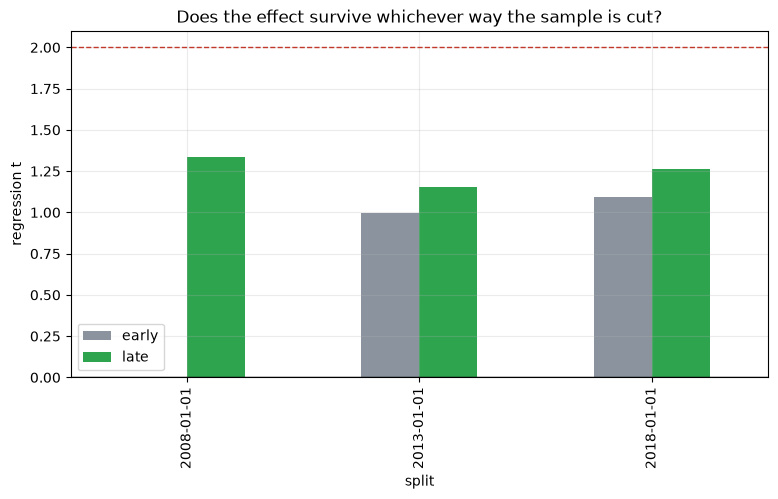

In [8]:
rows = []
for split in ("2008-01-01", "2013-01-01", "2018-01-01"):
    e = st.era_split(common, data.CANARY, data.MARKET, data.CASH, split=split)
    for era, r in e.iterrows():
        rows.append({"split": split, "era": era, "t": r["t"], "cagr_gap": r["cagr_gap"]})
d = pd.DataFrame(rows)
print(d.round(4).to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 4.5))
d.pivot(index="split", columns="era", values="t").plot.bar(ax=ax, color=["#8b949e", "#2ea44f"])
ax.axhline(0, color="k", lw=1); ax.axhline(2, ls="--", color="#c0392b", lw=1)
ax.set_ylabel("regression t"); ax.legend(title="")
ax.set_title("Does the effect survive whichever way the sample is cut?")
plt.show()

### 3.6 The synthetic control

              lead-lag difference  regression t  rule CAGR gap
planted lead                                                  
0.0000                     0.0030        0.3529        -0.0152
0.1000                     0.1201        1.4836         0.0461
0.2500                     0.2757        3.5669         0.1627
0.5000                     0.4542        6.9729         0.3922


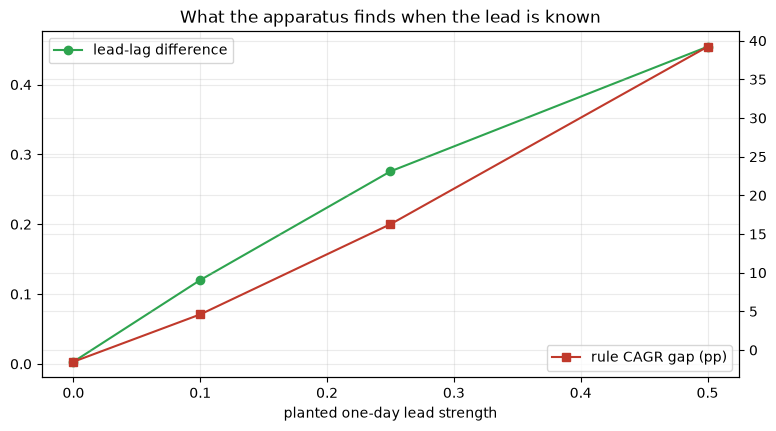

In [9]:
rows = []
for strength in (0.0, 0.1, 0.25, 0.5):
    lls, ts, gaps = [], [], []
    for s in range(6):
        sim = st.synthetic_pair(n=5000, lead_strength=strength, seed=980 + s)
        lls.append(st.lead_lag_table(sim, "SEC", "MKT", max_lag=2).loc[1, "difference"])
        ts.append(st.predictive_regression(sim, "SEC", "MKT", horizon=5, lookback=5)["t"])
        gaps.append(st.timing_rule(sim, "SEC", "MKT", "CASH", lookback=5)["cagr_gap"])
    rows.append({"planted lead": strength, "lead-lag difference": np.mean(lls),
                 "regression t": np.mean(ts), "rule CAGR gap": np.mean(gaps)})
d = pd.DataFrame(rows).set_index("planted lead")
print(d.round(4).to_string())
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(d.index, d["lead-lag difference"], marker="o", color="#2ea44f", label="lead-lag difference")
ax2 = ax.twinx()
ax2.plot(d.index, d["rule CAGR gap"] * 100, marker="s", color="#c0392b",
         label="rule CAGR gap (pp)")
ax.set_xlabel("planted one-day lead strength"); ax.legend(loc="upper left")
ax2.legend(loc="lower right")
ax.set_title("What the apparatus finds when the lead is known")
plt.show()

## 4 · The verdict

In [10]:
rule = st.timing_rule(common, data.CANARY, data.MARKET, data.CASH, lookback=21,
                      cost_bps=2.0)
reg = st.predictive_regression(common, data.CANARY, data.MARKET, horizon=21, lookback=21)
ll = st.lead_lag_table(common, data.CANARY, data.MARKET, max_lag=2)
pd.DataFrame({
    "lead-lag difference at lag 1": [ll.loc[1, "difference"]],
    "regression slope": [reg["beta"]],
    "HAC t": [reg["t"]],
    "R2": [reg["r2"]],
    "rule CAGR gap": [rule["cagr_gap"]],
    "rule Sharpe gap": [rule["sharpe_gap"]],
    "rule drawdown vs hold": [rule["strategy"]["max_dd"] - rule["buy_hold"]["max_dd"]],
}).T.rename(columns={0: "value"}).round(4)

,value
lead-lag difference at lag 1,0.1318
regression slope,2.3490
HAC t,1.5885
R2,0.0104
rule CAGR gap,-0.0051
rule Sharpe gap,0.1298
rule drawdown vs hold,0.2382


## 5 · Going further

- **Firm-level economic links** (Cohen & Frazzini 2008; Menzly & Ozbas 2010) are where this
  mechanism is documented to work — customers and suppliers, not indices.
- **Book-to-bill and billings**: the fundamental series the claim is really about.
- **Concentration-adjusted**: strip the largest constituent out of both semiconductor funds
  and repeat, to see whether the canary is a sector or a stock.
- **Intraday**: if the lead is one day at daily frequency, most of it may live inside the
  overnight session — testable with intraday data this desk does not have.